# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.13.15 | pandas 2.2.3 | seaborn 0.13.2


In [2]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [3]:
def missing_report(frame):
    """Return a DataFrame describing the missing values of `frame`.
    ...
    """
    missing_counts = frame.isna().sum()                    # Series: кількість NaN у кожній
                                                           # колонці, індекс — назви колонок
    missing_counts = missing_counts[missing_counts > 0]    # лишаємо лише ті колонки, де є
                                                           # хоч один пропуск — решта відкидається
                                                           # повністю, як і вимагає умова

    percent = 100 * missing_counts / len(frame)            # частка від загальної кількості
                                                           # РЯДКІВ (len(frame)), а не від суми
                                                           # усіх пропусків по всіх колонках

    report = pd.DataFrame({
        "missing": missing_counts.astype(int),             # явно int, а не numpy-int64/float
        "percent": percent.round(2),                       # округлення до 2 знаків, як вимагає умова
    })

    return report.sort_values("missing", ascending=False)  # за спаданням; індекс DataFrame
                                                           # лишається назвами колонок, бо
                                                           # sort_values не чіпає індекс

In [4]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [5]:
def first_and_labelled(frame, sort_column, label):
    """Sort `frame` by `sort_column` descending, then return a tuple:
        (top_row, labelled_row)
    ...
    """
    sorted_frame = frame.sort_values(sort_column, ascending=False)
    # sort_values переставляє РЯДКИ, але мітки індексу подорожують разом з ними —
    # індекс НЕ переприсвоюється (немає reset_index), як і вимагає умова

    top_row = sorted_frame.iloc[0]            # "перша позиція в новому порядку" -> iloc,
                                              # позиційний доступ, не залежить від значення мітки
    labelled_row = sorted_frame.loc[label]    # "рядок з міткою label" -> loc, доступ за
                                              # конкретною міткою індексу, незалежно від того,
                                              # на яку позицію цей рядок потрапив після сортування

    return top_row, labelled_row

In [6]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Cardeza, Mr. Thomas Drake Martinez | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [7]:
def fill_age_by_group(frame):
    """Return a COPY of `frame` with missing 'Age' filled by the median age
    of the passenger's (Pclass, Sex) group.
    ...
    """
    result = frame.copy()    # аргумент не можна чіпати -> одразу працюємо з копією,
                             # а не з frame напряму

    group_median = result.groupby(["Pclass", "Sex"])["Age"].transform("median")
    # transform (на відміну від agg) повертає Series ТІЄЇ Ж довжини й того самого
    # індексу, що й result["Age"] — по одному значенню медіани групи НА КОЖЕН
    # пасажир, а не по одному числу на групу; саме тому його можна напряму
    # використати у fillna без жодного merge чи циклу

    result["Age"] = result["Age"].fillna(group_median)
    return result

In [8]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [9]:
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values.
    ...
    """
    series = frame[column]

    strategies = {
        "dropna": series.dropna(),                            # просто викинути пропуски —
                                                              # n падає, решта статистик
                                                              # рахуються по "чесних" 714
        "mean": series.fillna(series.mean()),                 # глобальне середнє на місце NaN
        "median": series.fillna(series.median()),             # глобальна медіана на місце NaN
        "group_median": series.fillna(                        # медіана (Pclass, Sex)-групи —
            frame.groupby(["Pclass", "Sex"])[column].transform("median")
        ),
    }

    rows = {
        name: {
            "n": int(values.size),
            "mean": values.mean(),
            "median": values.median(),
            "std": values.std(),   # ddof=1 — pandas-дефолт, як і вимагає умова
        }
        for name, values in strategies.items()
    }

    report = pd.DataFrame(rows).T    # .T: ключі словника (назви стратегій) стають
                                     # рядками-мітками, а не колонками

    # явно фіксуємо порядок рядків і колонок, а не покладаємось на порядок вставки
    return report.loc[["dropna", "mean", "median", "group_median"], ["n", "mean", "median", "std"]]

In [10]:
_comparison = compare_imputations(titanic)

assert list(_comparison.index) == ["dropna", "mean", "median", "group_median"]
assert list(_comparison.columns) == ["n", "mean", "median", "std"]
assert _comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert _comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(_comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert _comparison.loc["mean", "std"] < _comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert _comparison.loc["group_median", "std"] > _comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(_comparison.round(4))
print("\nTask 4 passed.")

                    n    mean  median     std
dropna       714.0000 29.6991 28.0000 14.5265
mean         891.0000 29.6991 29.6991 13.0020
median       891.0000 29.3616 28.0000 13.0197
group_median 891.0000 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

                    n    mean  median     std
dropna       714.0000 29.6991 28.0000 14.5265
mean         891.0000 29.6991 29.6991 13.0020
median       891.0000 29.3616 28.0000 13.0197
group_median 891.0000 29.1124 26.0000 13.3044

частка пропусків Age по групах (Pclass, Sex):
Pclass  Sex   
1       female   0.0957
        male     0.1721
2       female   0.0263
        male     0.0833
3       female   0.2917
        male     0.2709
Name: Age, dtype: float64

середній вік за класом (серед відомих): {1: 38.2, 2: 29.9, 3: 25.1}


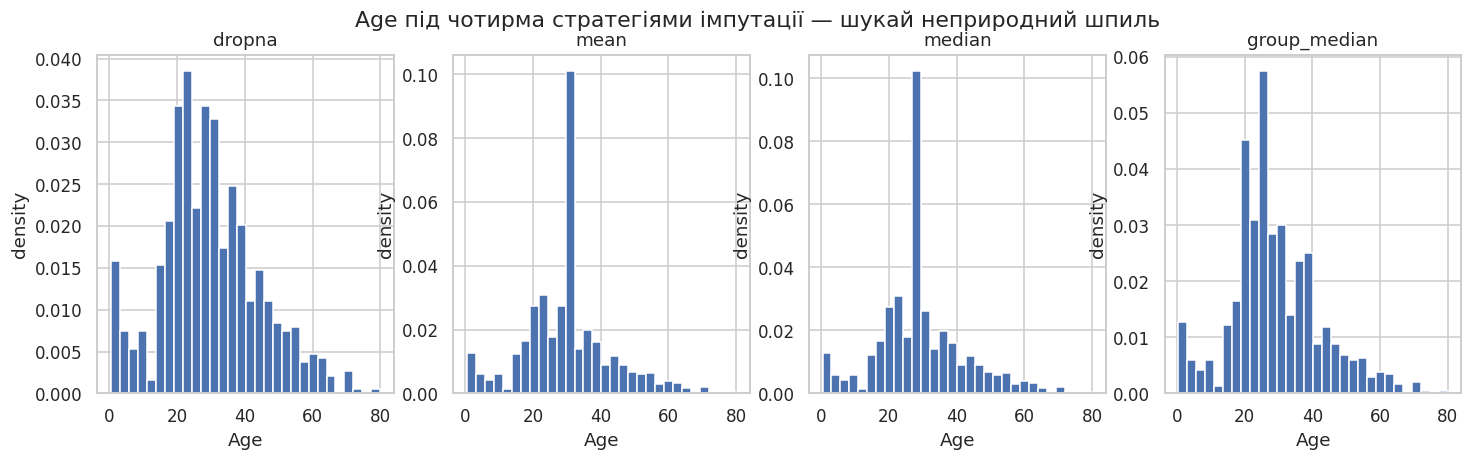

In [11]:
report = compare_imputations(titanic, column="Age")
print(report.round(4))

# --- (a) гістограми чотирьох варіантів поруч ---
strategies = {
    "dropna": titanic["Age"].dropna(),
    "mean": titanic["Age"].fillna(titanic["Age"].mean()),
    "median": titanic["Age"].fillna(titanic["Age"].median()),
    "group_median": titanic["Age"].fillna(
        titanic.groupby(["Pclass", "Sex"])["Age"].transform("median")
    ),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, values) in zip(axes, strategies.items()):
    ax.hist(values, bins=30, density=True)
    ax.set_xlabel("Age")
    ax.set_ylabel("density")
    ax.set_title(name)
fig.suptitle("Age під чотирма стратегіями імпутації — шукай неприродний шпиль")

# --- (b) чи залежить частота пропусків Age від Pclass/Sex? ---
age_missing_rate = titanic.groupby(["Pclass", "Sex"])["Age"].apply(lambda s: s.isna().mean())
print("\nчастка пропусків Age по групах (Pclass, Sex):")
print(age_missing_rate.round(4))

print("\nсередній вік за класом (серед відомих):", titanic.groupby("Pclass")["Age"].mean().round(1).to_dict())

**Your answer:**

**(a)** Заповнення середнім справді лишає `mean` абсолютно незмінним — це математично гарантовано, бо додавання 177 копій самого середнього до решти значень не зсуває середнє арифметичне жодного разу. Але пошкодженою виявляється **дисперсія/std**: у таблиці `std` при `mean`-заповненні падає приблизно з 14.5 (dropna) до 13.0 — 177 значень (20% вибірки) штучно стискаються в одну точку, і на гістограмі це видно як неприродний вузький шпиль рівно на значенні середнього, якого в реальному розподілі віку немає. Збереження середнього не робить заповнення нешкідливим, бо `mean` — лише одна вузька статистика; усе інше, що залежить від розкиду (std, кореляції з Age, квантилі, довірчі інтервали, будь-яка регресія, що використовує Age як ознаку чи предиктор), спотворюється цим штучним "кластером" однакових значень. На рівні окремого рядка помилка теж цілком реальна — для конкретного пасажира підставлене середнє майже напевно не є його справжнім віком, і те, що ця помилка в середньому по всій вибірці "гаситься" до нуля, не означає, що вона зникла для кожного окремого спостереження чи для будь-якої іншої статистики, крім самого mean.

**(b)**  `dropna` дає незміщені оцінки тоді й лише тоді, коли пропуски **MCAR** (Missing Completely At Random) — тобто ймовірність того, що вік не записаний, ніяк не пов'язана ні з самим віком, ні з жодною іншою змінною в датасеті. Тоді 714 рядків, що лишились — це чесна випадкова підвибірка з 891, і статистики на ній зміщення не мають (лише вищу дисперсію через менший n). Для Titanic-`Age` це припущення **малоймовірне**: сам факт, що стратегія `group_median` (умовно на Pclass і Sex) взагалі має сенс як покращення, вже неявно визнає, що пропуски пов'язані зі спостережуваними змінними — а це і є визначення **MAR** (Missing At Random, умовно на Pclass/Sex), а не MCAR. Пряма перевірка — таблиця частки пропусків Age по групах (Pclass, Sex) вище: у 2-му класі вік не записано лише в 2.6% жінок і 8.3% чоловіків, у 1-му — у 9.6% і 17.2%, а в 3-му — у 29.2% і 27.1%. Ймовірність пропуску в 3-му класі приблизно в десять разів вища, ніж серед жінок 2-го класу, — це конкретний доказ проти MCAR і на користь MAR (пропуск залежить від спостережуваного класу). А оскільки пасажири 3-го класу в середньому молодші, `dropna` систематично недопредставляє молодших і зсуває оцінку віку вгору.

 **(c)** Обираю **`group_median`**. По-перше, вона єдина з чотирьох враховує структуру пропусків, яку (b) показує як MAR-подібну — умовлюючись на Pclass і Sex, вона наближається до того, яким міг би бути справжній вік пасажира в його групі, а не приписує всім однакове глобальне число. По-друге, вона зберігає весь обсяг вибірки (n=891, на відміну від dropna, що втрачає 20% рядків) і не деформує std настільки різко, як `mean`/`median` (13.30 проти 13.00/13.02, ближче до чесних 14.53 з dropna). Це не ідеальне рішення — залишкове зміщення в межах групи все одно можливе, якщо MAR-припущення виконується не повністю, — але серед чотирьох доступних варіантів воно найкраще балансує збереження даних і мінімізацію штучного спотворення розподілу.

## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [12]:
def iqr_outliers(series, multiplier=1.5):
    """Flag the values of `series` outside the 1.5 x IQR fences.
    ...
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    # NaN < lower і NaN > upper обидва дають False (порівняння з NaN завжди False,
    # окрім !=) — тому пропуски автоматично НЕ потрапляють у mask як True,
    # без потреби в окремому виклику isna(). Саме це й гарантує вимогу
    # "Missing values are never outliers".
    mask = (series < lower) | (series > upper)

    return {
        "q1": float(q1),
        "q3": float(q3),
        "lower": float(lower),
        "upper": float(upper),
        "mask": mask,
    }

In [13]:
_fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(_fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(_fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {_fare['q1']}"
assert np.isclose(_fare["q3"], 31.0, atol=1e-6), f"Q3 wrong: {_fare['q3']}"
assert np.isclose(_fare["upper"], 65.6344, atol=1e-3), f"upper fence wrong: {_fare['upper']}"
assert _fare["mask"].dtype == bool
assert int(_fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(_fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= _fare["mask"].sum()

# Missing values must not be flagged.
_age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not _age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(_age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {_fare['q1']:.2f}, Q3 {_fare['q3']:.2f}, "
      f"fences [{_fare['lower']:.2f}, {_fare['upper']:.2f}], {int(_fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00, fences [-26.72, 65.63], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

In [14]:
# --- (a) Fare: IQR при кількох множниках + 3-сигма (без sigma_outliers) ---
multipliers = [1.0, 1.5, 3.0, 5.0]
rows = []
for m in multipliers:
    result = iqr_outliers(titanic["Fare"], multiplier=m)
    rows.append({"rule": f"IQR x{m}", "count": int(result["mask"].sum()),
                 "lower": result["lower"], "upper": result["upper"]})

fare_mean, fare_std = titanic["Fare"].mean(), titanic["Fare"].std()
fare_lower, fare_upper = fare_mean - 3 * fare_std, fare_mean + 3 * fare_std
sigma_mask = (titanic["Fare"] < fare_lower) | (titanic["Fare"] > fare_upper)  # NaN тут не заважає: порівняння з NaN дає False, як і в Task 5
rows.append({"rule": "3-sigma", "count": int(sigma_mask.sum()),
             "lower": fare_lower, "upper": fare_upper})

comparison_fare = pd.DataFrame(rows).set_index("rule")
print("Fare:")
print(comparison_fare.round(2))
print(f"\nFare shape: mean={fare_mean:.2f}  median={titanic['Fare'].median():.2f}  std={fare_std:.2f}")

# --- (c) те саме для Age ---
age = titanic["Age"].dropna()
rows_age = []
for m in multipliers:
    result = iqr_outliers(age, multiplier=m)
    rows_age.append({"rule": f"IQR x{m}", "count": int(result["mask"].sum())})

age_mean, age_std = age.mean(), age.std()
age_lower, age_upper = age_mean - 3 * age_std, age_mean + 3 * age_std
sigma_mask_age = (age < age_lower) | (age > age_upper)
rows_age.append({"rule": "3-sigma", "count": int(sigma_mask_age.sum())})

comparison_age = pd.DataFrame(rows_age).set_index("rule")
print("\nAge:")
print(comparison_age)
print(f"\nAge shape: mean={age_mean:.2f}  median={age.median():.2f}  std={age_std:.2f}")

# (d) хто ці пасажири з максимальним Fare
print("\nпасажири з Fare > 500:")
print(titanic.loc[titanic["Fare"] > 500, ["Name", "Pclass", "Survived", "Fare"]])

Fare:
          count     lower    upper
rule                              
IQR x1.0    141  -15.1800  54.0900
IQR x1.5    116  -26.7200  65.6300
IQR x3.0     53  -61.3600 100.2700
IQR x5.0     31 -107.5400 146.4500
3-sigma      20 -116.8800 181.2800

Fare shape: mean=32.20  median=14.45  std=49.69

Age:
          count
rule           
IQR x1.0     63
IQR x1.5     11
IQR x3.0      0
IQR x5.0      0
3-sigma       2

Age shape: mean=29.70  median=28.00  std=14.53

пасажири з Fare > 500:
                                   Name  Pclass  Survived     Fare
258                    Ward, Miss. Anna       1         1 512.3292
679  Cardeza, Mr. Thomas Drake Martinez       1         1 512.3292
737              Lesurer, Mr. Gustave J       1         1 512.3292


**Your answer:**

**(a)** На Fare `IQR`-правило позначає **141** точку при множнику 1.0, **116** при 1.5 (межі [−26.72, 65.63]), **53** при 3.0 і **31** при 5.0 — кількість монотонно спадає, бо межі розширюються. `3-сигма` позначає лише **20** точок (межі [−116.88, 181.28]), тобто менше, ніж навіть найм'якше з перевірених IQR-правил (x5.0). Нижня межа в усіх правилах від'ємна, тож усі позначені точки — дорогі квитки; вибір множника вирішує, чи 116, чи 31 пасажир вважатиметься «викидом», і ця різниця — це саме рішення аналітика, а не властивість даних.

**(b)** Причина розбіжності — сильна правостороння скошеність `Fare`: медіана (~14.45) набагато менша за середнє (32.20), а максимум (512.33) у десятки разів більший за типове значення. `IQR`-правило будується на квантилях (Q1, Q3) — це робастні статистики: додавання ще однієї екстремальної точки чи навіть зсув наявних викидів ще далі не змінює Q1/Q3 взагалі, поки не міняється їхній ранг серед решти значень. **3σ-правило, натомість, будується на mean/std — і саме std тут "інфлюється" тими самими точками, які має ловити**: три пасажири з Fare = 512.33 (вивід вище) дають величезний внесок у дисперсію (квадрат відхилення), тому std роздувається, межа `mean ± 3·std` розтягується значно ширше, ніж мала б бути для "типової" маси даних — і частина реальних викидів більше не потрапляє за цю розтягнуту межу. Це той самий ефект маскування (masking), що й у задачі з `mystery_sample`: викиди спотворюють саме ту оцінку, яка мала б їх виявляти.

**(c)** На `Age` картина інша: IQR x1.5 позначає 11 точок, 3-сигма — 2, а при x3.0 і x5.0 не позначено жодної. Різниця між правилами в абсолютних числах невелика і ніде не доходить до сотні, як у Fare. Причина в тому, що `Age` не має настільки екстремальної скошеності: `mean` і `median` у `Age` близькі одне до одного (~29.7 і ~28.0, різниця невелика, на відміну від Fare, де різниця в рази), а максимум (80) не є на порядки більшим за типове значення, як 512.33 проти медіани ~14 у Fare. Оскільки розподіл `Age` набагато ближчий до симетричного/приблизно нормального, припущення, на якому базується 3σ-правило (дані приблизно гаусові), тут значно краще виконується — тому робастна (IQR) і нестійка до викидів (3σ) оцінки дають набагато схожіші межі й кількість флагів.

**(d)** Ні, я б не видаляв позначені точки Fare. `Fare` — це реальна ціна квитка, а не показник приладу, що може "зламатися": відома історична структура квитків на Titanic включала як майже безкоштовні квитки третього класу, так і окремі розкішні каюти першого класу. Троє пасажирів з Fare = 512.33 (вивід вище: Ward, Cardeza, Lesurer) — усі з 1-го класу і всі вижили, тобто це узгоджені між собою реальні записи, а не збій. Це факт про ЗМІСТ колонки (ціна легітимно охоплює величезний діапазон через реальну класову стратифікацію пасажирів), а не про поріг: видалення цих рядків означало б викинути справжніх пасажирів найдорожчих кают із будь-якого аналізу зв'язку Fare і виживання, спотворивши висновок, а не очистивши його.

## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [15]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns.
    ...
    """
    pearson = frame[column_a].corr(frame[column_b], method="pearson")     # чутливий лише до ЛІНІЙНОГО зв'язку між величинами
    spearman = frame[column_a].corr(frame[column_b], method="spearman")   # рахується на РАНГАХ, тому ловить будь-який МОНОТОННИЙ (не обов'язково лінійний) зв'язок

    return {
        "pearson": float(pearson),
        "spearman": float(spearman),
        "difference": float(pearson - spearman),
    }

In [16]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
_linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
_lin = correlation_pair(_linear, "a", "b")
assert np.isclose(_lin["pearson"], 1.0) and np.isclose(_lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
_curve_rng = np.random.default_rng(SEED)
_x = np.linspace(0.1, 5.0, 300)
_curved = pd.DataFrame({"x": _x, "y": np.exp(_x) + _curve_rng.normal(0, 3, 300)})
_c = correlation_pair(_curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:+.4f}  "
      f"spearman {_pair['spearman']:+.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:+.4f}  "
      f"spearman {_c['spearman']:+.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson +0.8646  spearman +0.8794
curved monotonic pair          : pearson +0.8605  spearman +0.9653
Task 6 passed.


### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

_curved: {'pearson': 0.8604745752639905, 'spearman': 0.9653178368648541, 'difference': -0.10484326160086355}

wine color_intensity vs hue: {'pearson': -0.5218131932287577, 'spearman': -0.4185217619000421, 'difference': -0.10329143132871565}

частка цілих значень Age: 0.965 (n=714)
Age=30: 25 пасажирів   сусіди 29/31: 20/17
Age=35: 18 пасажирів   сусіди 34/36: 15/22
Age=40: 13 пасажирів   сусіди 39/41: 14/6
Age=45: 12 пасажирів   сусіди 44/46: 9/3
Age=50: 10 пасажирів   сусіди 49/51: 6/7
пасажирів з віком < 10: 62


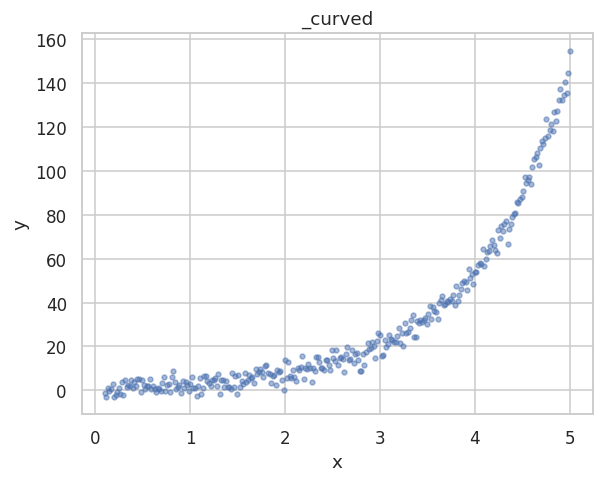

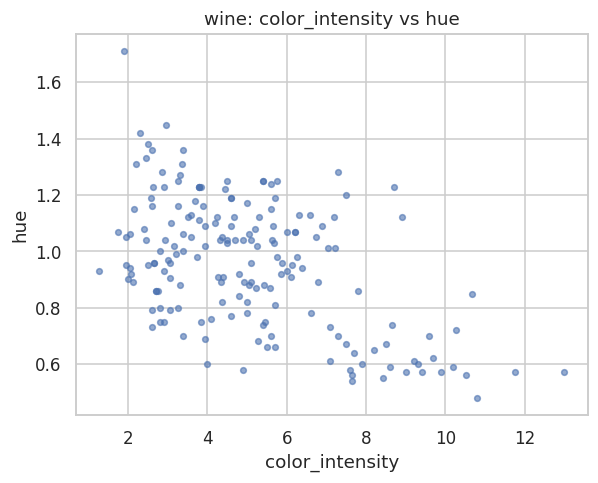

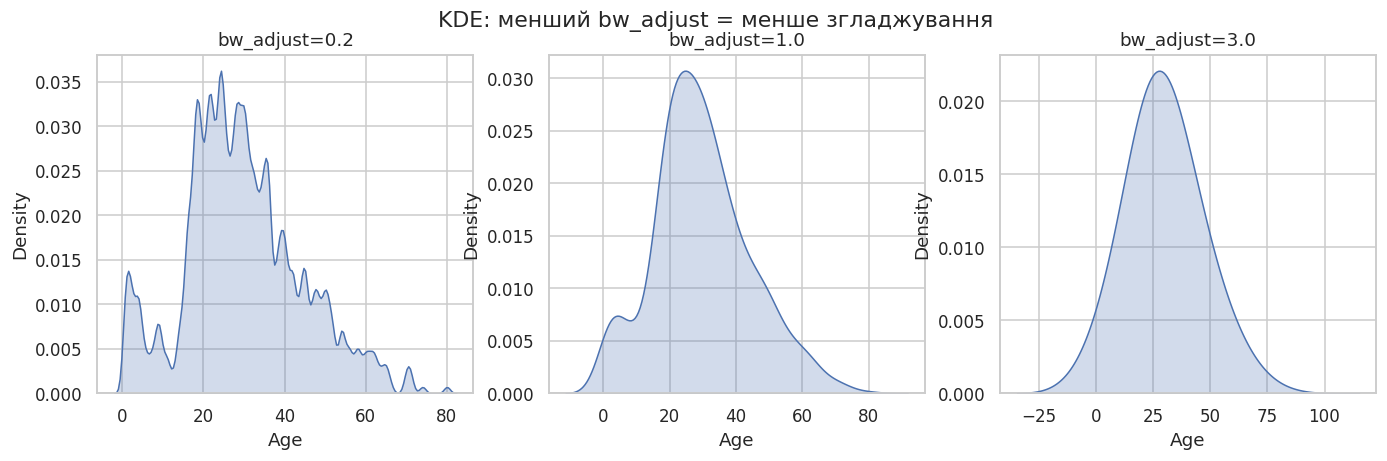

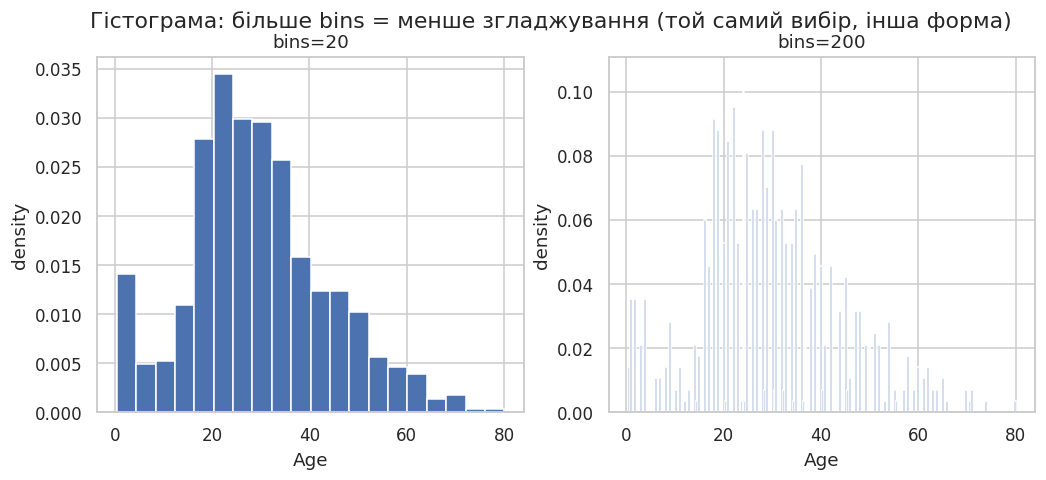

In [17]:
# --- (a) _curved: розсіювання + два коефіцієнти ---
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(_curved["x"], _curved["y"], s=10, alpha=0.5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("_curved")

curved_corr = correlation_pair(_curved, "x", "y")
print("_curved:", curved_corr)

# --- (b) wine: color_intensity vs hue ---
wine_corr = correlation_pair(wine, "color_intensity", "hue")
print("\nwine color_intensity vs hue:", wine_corr)

fig2, ax2 = plt.subplots(figsize=(6, 4.5))
ax2.scatter(wine["color_intensity"], wine["hue"], s=14, alpha=0.6)
ax2.set_xlabel("color_intensity")
ax2.set_ylabel("hue")
ax2.set_title("wine: color_intensity vs hue")

# --- (c) Age: та сама "гострота погляду" через KDE bandwidth і bin count ---
fig3, axes3 = plt.subplots(1, 3, figsize=(15, 4))
for ax, bw in zip(axes3, (0.2, 1.0, 3.0)):
    sns.kdeplot(titanic["Age"].dropna(), bw_adjust=bw, ax=ax, fill=True)
    ax.set_xlabel("Age")
    ax.set_title(f"bw_adjust={bw}")
fig3.suptitle("KDE: менший bw_adjust = менше згладжування")

fig4, axes4 = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, bins in zip(axes4, (20, 200)):
    ax.hist(titanic["Age"].dropna(), bins=bins, density=True)
    ax.set_xlabel("Age")
    ax.set_ylabel("density")
    ax.set_title(f"bins={bins}")
fig4.suptitle("Гістограма: більше bins = менше згладжування (той самий вибір, інша форма)")

# числа для (c): чи вік записаний цілими/круглими значеннями
_age = titanic["Age"].dropna()
print(f"\nчастка цілих значень Age: {(_age == _age.round()).mean():.3f} (n={len(_age)})")
_vc = _age.value_counts()
for a in (30, 35, 40, 45, 50):
    print(f"Age={a}: {_vc.get(float(a), 0):>2} пасажирів   сусіди {a-1}/{a+1}: "
          f"{_vc.get(float(a-1), 0)}/{_vc.get(float(a+1), 0)}")
print("пасажирів з віком < 10:", int((_age < 10).sum()))

**Your answer:**

(a) Pearson рахує, наскільки добре точки лягають на пряму лінію; Spearman рахує кореляцію на рангах, тому ловить будь-який монотонний зв'язок (зростає/спадає завжди в один бік), незалежно від того, наскільки він вигнутий. _curved побудований так, що y монотонно зростає з x, але не лінійно (крива вигинається) — тому Spearman бачить майже ідеальний монотонний зв'язок і дає високе значення, а Pearson, вимірюючи саме лінійність, недооцінює силу зв'язку через саму кривизну — звідси Pearson нижчий: на `_curved` Pearson = 0.860, Spearman = 0.965 (різниця −0.105). Якщо я збираюся підганяти саме лінійну модель до цієї пари, я б повідомляв Pearson: він прямо відповідає на питання "наскільки добре пряма лінія опише ці дані", а високий Spearman тут був би оманливо оптимістичним — він каже, що залежність сильна і передбачувана, але не каже, що вона лінійна.

(b) Тут розбіжність — іншого типу: обидва коефіцієнти від'ємні й достатньо близькі один до одного за модулем (Pearson −0.52, Spearman −0.42), але не тому, що зв'язок вигнутий, а тому, що хмара color_intensity проти hue — це розсіяна, шумна хмара з поодинокими віддаленими точками, а не чистий монотонний тренд: частина спостережень відхиляється від загальної тенденції в обидва боки. Це саме той випадок, коли жодна крива ідеально не описує зв'язок — тому й Pearson, і Spearman дають помірні, а не близькі до ±1 значення, а різниця між ними відображає не кривизну (як у (a)), а просто загальний рівень шуму й розкиду точок навколо тренду.

(c) Це одне й те саме рішення: скільки згладжування застосувати до сирих даних, перш ніж на них дивитися. Менший bw_adjust у KDE ≈ більше bins у гістограмі — обидва звужують "вікно", крізь яке дивляться на точки, тому показують дрібнішу деталізацію. Більший bw_adjust ≈ менше bins — обидва розмазують сусідні точки в одну ширшу масу. Напрям "більше згладжування" (великий bw_adjust, мало bins) ховає реальну структуру — розтягує/зливає дрібні, але справжні особливості розподілу в один гладкий горб. Напрям "менше згладжування" (малий bw_adjust, багато bins) вигадує структуру — перетворює звичайний статистичний шум малих підвибірок на візуально переконливі, але не відтворювані піки й провали (та сама пастка, що й у Task 10/_mixture). На Age це видно з обох боків. При bw_adjust=3.0 зникає реальна структура: окремий горб дітей до 10 років (62 пасажири) зливається з основною масою, а крива ще й «вигадує» від'ємний вік — хвіст тягнеться до −25. При bw_adjust=0.2 крива вкривається десятком дрібних зубців. Частина з них — справжня особливість того, як записувався вік, а не демографії: 96.5% значень Age — цілі числа, а на круглих роках помітні надлишки (30 років — 25 пасажирів проти 20 і 17 у 29 і 31; 45 — 12 проти 9 і 3; 40 — 13 проти 14 і 6). Це класичне округлення приблизно відомого віку (age heaping). Решта зубців — шум малої вибірки. bw_adjust=1.0 показує і дитячий горб, і основний пік біля 25 без цих артефактів.

## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [18]:
from itertools import combinations

def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column.
    ...
    """
    categories = sorted(series.unique())              # алфавітний порядок — той самий, що дав би LabelEncoder
    label_code = {cat: i for i, cat in enumerate(categories)}

    # кодуємо саму КАТЕГОРІЮ, а не рядки series — вектор one-hot для категорії
    # будується напряму зі списку categories, без пошуку конкретного рядка даних
    onehot_code = {
        cat: np.array([1.0 if cat == other else 0.0 for other in categories])
        for cat in categories
    }

    rows = {}
    for a, b in combinations(categories, 2):
        # categories вже відсортовані -> combinations() завжди дає a РАНІШЕ b
        # за алфавітом у кожній парі, тому індекс "A|B" одразу правильний
        label_distance = abs(label_code[a] - label_code[b])
        onehot_distance = float(np.linalg.norm(onehot_code[a] - onehot_code[b]))
        rows[f"{a}|{b}"] = {"label_distance": label_distance, "onehot_distance": onehot_distance}

    return pd.DataFrame(rows).T.sort_index()

In [19]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

     label_distance  onehot_distance
C|Q          1.0000           1.4142
C|S          2.0000           1.4142
Q|S          1.0000           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

In [20]:
original_order = ["Cherbourg", "Queenstown", "Southampton"]   # вихідний алфавітний порядок
original_codes = {name: i for i, name in enumerate(original_order)}
print("оригінальні коди:", original_codes)
print("C-Q:", abs(original_codes["Cherbourg"] - original_codes["Queenstown"]))
print("C-S:", abs(original_codes["Cherbourg"] - original_codes["Southampton"]))
print("Q-S:", abs(original_codes["Queenstown"] - original_codes["Southampton"]))

# перейменовуємо так, щоб АЛФАВІТНИЙ порядок став Queenstown, Southampton, Cherbourg
renamed_order = ["Queenstown", "Southampton", "Cherbourg"]
renamed_codes = {name: i for i, name in enumerate(renamed_order)}
print("\nкоди після перейменування:", renamed_codes)
print("Q-S:", abs(renamed_codes["Queenstown"] - renamed_codes["Southampton"]))
print("Q-C:", abs(renamed_codes["Queenstown"] - renamed_codes["Cherbourg"]))
print("S-C:", abs(renamed_codes["Southampton"] - renamed_codes["Cherbourg"]))

оригінальні коди: {'Cherbourg': 0, 'Queenstown': 1, 'Southampton': 2}
C-Q: 1
C-S: 2
Q-S: 1

коди після перейменування: {'Queenstown': 0, 'Southampton': 1, 'Cherbourg': 2}
Q-S: 1
Q-C: 2
S-C: 1


**Your answer:**

(a) До перейменування: C=0, Q=1, S=2 → C-Q=1, C-S=2, Q-S=1 — Queenstown лежить "між" Cherbourg і Southampton, а Cherbourg і Southampton — найбільш "далекі" одна від одної (відстань 2). Після перейменування (новий алфавітний порядок Queenstown, Southampton, Cherbourg): Q=0, S=1, C=2 → Q-S=1, Q-C=2, S-C=1 — тепер вже Southampton лежить "між" двома іншими, а найбільш "далекою" парою стала Queenstown і Cherbourg. Геометрія повністю перевернулась: жоден реальний факт про ці три порти не змінився, змінилось лише те, як вони називались — а отже, і те, в якому порядку літери їхніх назв стоять в алфавіті. Це означає, що уявлення моделі про "схожість" між категоріями в такому кодуванні — це не властивість самих даних, а побічний ефект того, якими іменами ці категорії названі: перейменування, яке нічого не змінює по суті (ті самі три порти, ті самі пасажири), може повністю переставити, які категорії модель вважає близькими, а які — далекими.

(b) Точна відмінність: у Pclass категорії лежать на одній реальній осі — існує зовнішній, незалежний від кодування факт, що 1-й клас "вищий" за 2-й, а 2-й "вищий" за 3-й (комфорт, ціна, привілеї), і ця сама вісь визначає як порядок, так і відносну відстань між категоріями: 1 і 3 справді "далі одна від одної" по цій осі, ніж 1 і 2. У Embarked немає жодної подібної спільної осі — Шербур, Квінстаун і Саутгемптон не лежать на жодній природній шкалі "менше-більше"; єдиний порядок, який у них взагалі можна вигадати (наприклад, алфавітний), не відповідає жодному реальному виміру, як показує (a): він змінюється разом з іменами, а не з фактами про порти. Тобто кодування коректне тоді, коли категорії справді впорядковані по чомусь реальному, і некоректне — коли єдиний доступний порядок довільний.

(c) Дерева рішень (і будь-які їхні ансамблі — random forest, gradient boosting): дерево ніколи не обчислює відстань між закодованими значеннями, воно лише запитує "це значення менше/більше за поріг X?" по одній ознаці за раз, і при потребі може виділити будь-яку окрему категорію чи групу категорій послідовністю з кількох таких порогових розбиттів — незалежно від того, якими конкретно числами категорії позначені. Це вже було видно в практичній: множення "найслабшої" ознаки на 1000 не змінило точність дерева (0.9333→0.9333 незмінно), тоді як KNN, який справді рахує евклідову відстань, різко просів (0.9667→0.7733) — саме тому, що для дерева важливий лише відносний порядок значень для розбиття, а не вигадана "відстань" між ними.

## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardise WITHOUT leakage.
    ...
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,                 # зберігає баланс класів однаковим в train і test, а не лише орієнтовно
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)  # fit ТІЛЬКИ на train -> scaler "бачить" лише навчальні рядки
    X_test_scaled = scaler.transform(X_test)        # test лише transform, БЕЗ fit — інакше scaler підглянув би розподіл test-даних ще до того, як модель має право його побачити

    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler,
    }

In [22]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised...
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "the training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "the training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "the test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
_leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, _leaky.mean_), \
    "your scaler's means match a scaler fitted on the whole dataset"

# stratify= must preserve the class balance
_train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
_full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_train_balance, _full_balance, atol=0.02), \
    "the class balance was not preserved; did you pass stratify=y?"

print("train", _split["X_train"].shape, " test", _split["X_test"].shape)
print("train mean (first 3 features):", _split["X_train"].mean(axis=0)[:3].round(10))
print("test  mean (first 3 features):", _split["X_test"].mean(axis=0)[:3].round(4), " <- not zero, correctly")
print("\nTask 8 passed.")

train (124, 13)  test (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test  mean (first 3 features): [-0.0324  0.0259 -0.0291]  <- not zero, correctly

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [23]:
from sklearn.preprocessing import MinMaxScaler

def split_and_scale_minmax(X, y, test_size=0.3, random_state=SEED):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y,
    )
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)   # min/max вивчені ЛИШЕ на train
    X_test_scaled = scaler.transform(X_test)          # test лише transform, ті самі
                                                        # min/max, що й для train
    return {"X_train": X_train_scaled, "X_test": X_test_scaled,
            "y_train": y_train, "y_test": y_test, "scaler": scaler}

_features = [c for c in wine.columns if c != "target"]

# --- (a) StandardScaler проти MinMaxScaler на реальних даних ---
standard_split = split_and_scale(wine[_features].values, wine["target"].values)
minmax_split = split_and_scale_minmax(wine[_features].values, wine["target"].values)

print("StandardScaler test: min", standard_split["X_test"].min().round(4),
      " max", standard_split["X_test"].max().round(4))
print("MinMaxScaler  test: min", minmax_split["X_test"].min().round(4),
      " max", minmax_split["X_test"].max().round(4))

# --- (b) один екстремум: найбільший proline x50 ---
proline_idx = _features.index("proline")
X_extreme = wine[_features].values.copy()
max_row = X_extreme[:, proline_idx].argmax()
X_extreme[max_row, proline_idx] *= 50

standard_extreme = split_and_scale(X_extreme, wine["target"].values)
minmax_extreme = split_and_scale_minmax(X_extreme, wine["target"].values)

print("\nПісля x50 на найбільший proline, колонка proline у TRAIN:")
print("StandardScaler: min", standard_extreme["X_train"][:, proline_idx].min().round(3),
      " max", standard_extreme["X_train"][:, proline_idx].max().round(3))
print("MinMaxScaler  : min", minmax_extreme["X_train"][:, proline_idx].min().round(3),
      " max", minmax_extreme["X_train"][:, proline_idx].max().round(3))

print("\nMinMax proline, перші 5 значень ДО екстремуму:",
      minmax_split["X_train"][:, proline_idx][:5].round(4))
print("MinMax proline, перші 5 значень ПІСЛЯ екстремуму:",
      minmax_extreme["X_train"][:, proline_idx][:5].round(4))

StandardScaler test: min -2.5321  max 4.7572
MinMaxScaler  test: min -0.0436  max 1.1358

Після x50 на найбільший proline, колонка proline у TRAIN:
StandardScaler: min -0.151  max 11.081
MinMaxScaler  : min 0.0  max 1.0

MinMax proline, перші 5 значень ДО екстремуму: [0.3022 0.5576 0.2806 0.1871 0.4173]
MinMax proline, перші 5 значень ПІСЛЯ екстремуму: [0.005  0.0093 0.0047 0.0031 0.0069]


**Your answer:**

(a) MinMaxScaler вивчає min і max лише з train, і формула (x - min_train) / (max_train - min_train) застосовується до test без жодних змін. Якщо в test-вибірці трапляється значення менше за min_train або більше за max_train (а це цілком нормально — train і test це різні випадкові підмножини, і немає причин, чому саме глобальний мінімум/максимум ознаки завжди потрапить у train), результат виходить за межі [0, 1]. Це не баг, а чесний сигнал: вивчений на train діапазон — лише оцінка справжнього діапазону ознаки, а не гарантована межа, і test, що виходить за цю оцінку, показує реальний факт — train не охопив увесь діапазон значень. У моєму спліті це й сталося: після MinMaxScaler test-значення лежать у діапазоні від −0.044 до 1.136, тобто трохи виходять за [0, 1] з обох боків (StandardScaler на тому самому test дає від −2.53 до 4.76, для нього такої «межі» просто немає). Якби ми примусово стиснули test у [0, 1] (наприклад, підігнавши scaler на об'єднаних train+test), це означало б використати інформацію про test ще до оцінювання — те саме витікання даних, яке Task 8 явно забороняє.

(b) MinMaxScaler набагато сильніше "розбитий" одним екстремальним значенням, і механізм тут прямий: параметри MinMax (min, max) — це самі граничні точки вибірки, тобто одне-єдине число (найбільший proline × 50) стає новим max і повністю визначає масштаб усієї колонки. Оскільки max - min тепер величезний, усі інші (нормальні) значення proline стискаються в крихітний відрізок біля 0 — саме це видно в порівнянні "до/після" у коді вище. StandardScaler, натомість, використовує std, яка є середнім по квадратах відхилень усіх точок разом — один екстремум справді роздуває std (бо його квадрат відхилення величезний), але цей вплив розмазується по всій вибірці, а не концентрується у двох граничних статистиках, як у MinMax. Це та сама картина, що й у демо з практичної: після множення найбільшого proline на 50 перші п'ять min-max-значень стиснулися з [0.19, 0.56] до [0.003, 0.009], тобто майже вся колонка злиплася біля нуля. У StandardScaler той самий екстремум теж зсуває шкалу (максимум тепер 11.08), але звичайні значення не злипаються в одну точку.

(c) Якщо "просочений" scaler (навчений на train+test разом) дає вищу точність, ця додаткова точність вимірює не краще узагальнення моделі, а те, наскільки саме процедура масштабування training-ознак вже "знала" про розподіл test-вибірки ще до оцінювання. Конкретно: mean/std (чи min/max) такого scaler обчислені з урахуванням test-рядків, тому коли він трансформує X_train, навчальні ознаки підлаштовуються під шкалу, яка частково відображає test-дані — модель навчається у "координатах", вже трохи зсунутих у бік test-розподілу. Оцінка на test після цього більше не вимірює здатність моделі узагальнюватись на дані, яких вона (і процедура підготовки даних) справді ніколи не бачила — вона частково вимірює те, наскільки легше стало передбачати test, коли сама шкала ознак вже "підказала" щось про його розподіл. Це точно те саме витікання, що й у демо selector_all/scaler outside pipeline з практичної: оптимістична цифра з практичної (0.77 замість чесних 0.50–0.52) — не показник якості моделі, а показник розміру витоку.

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [24]:
def components_for_variance(X, thresholds=(0.5, 0.8, 0.95, 0.99), standardise=True):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.
    ...
    """
    if standardise:
        X = StandardScaler().fit_transform(X)     # PCA на немасштабованих даних дозволив би
                                                  # ознаці з найбільшим розкидом (напр. proline)
                                                  # домінувати в першій компоненті лише через
                                                  # одиниці виміру, а не реальну структуру

    pca = PCA(random_state=SEED)    # без n_components -> залишає ВСІ компоненти,
                                    # random_state потрібен лише для детермінованості
                                    # знаку/порядку при виродженнях, сам результат
                                    # explained_variance_ratio_ від нього не залежить
    pca.fit(X)

    cumulative = np.cumsum(pca.explained_variance_ratio_)    # кумулятивна сума часток
                                                              # поясненої дисперсії,
                                                              # монотонно зростає до 1.0

    needed = {}
    for t in thresholds:
        # cumulative відсортований за побудовою (монотонно зростає), тому
        # searchsorted знаходить ПЕРШИЙ індекс, де cumulative[idx] >= t;
        # +1 переводить 0-базований індекс у "кількість компонентів"
        # (idx=0 означає, що вже саме ПЕРШОЇ компоненти достатньо -> needed=1)
        idx = int(np.searchsorted(cumulative, t))
        needed[t] = idx + 1

    return {"cumulative": cumulative, "needed": needed}

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardise=True)
_raw_result = components_for_variance(_X_wine, standardise=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print("standardised  :", _scaled_result["needed"])
print("not standardised:", _raw_result["needed"])
print(f"\nfirst component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised  : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}

first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

proline                        0.9998
magnesium                      0.0179
alcalinity_of_ash              0.0047
color_intensity                0.0023
alcohol                        0.0017
flavanoids                     0.0016
total_phenols                  0.0010
od280/od315_of_diluted_wines   0.0007
malic_acid                     0.0007
proanthocyanins                0.0006
ash                            0.0002
hue                            0.0002
nonflavanoid_phenols           0.0001
dtype: float64
частка дисперсії PC1: 0.9981


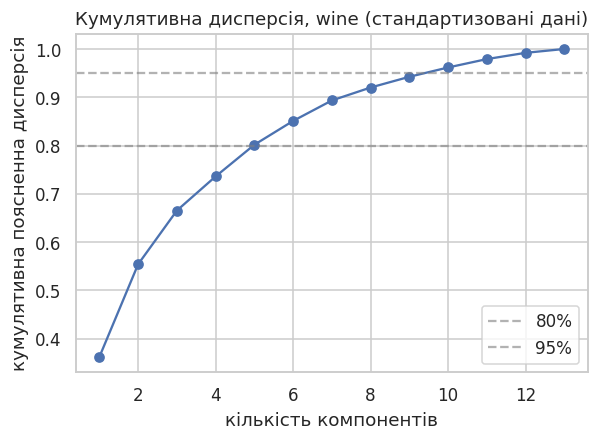

{0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}


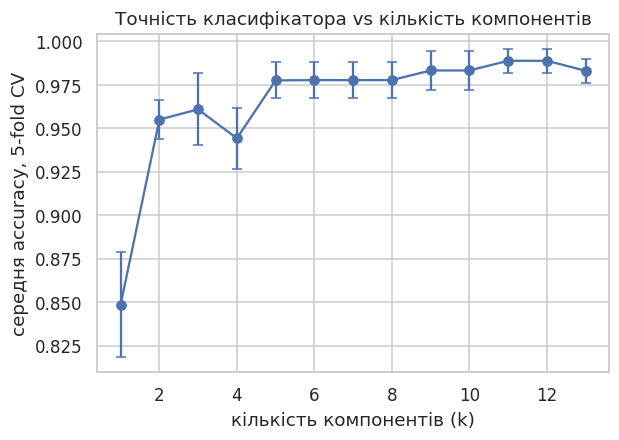

максимум CV-точності: k=11, accuracy=0.9889 ± 0.0068
правило одної стандартної похибки: найменше k з accuracy >= 0.9821 -> k=9 (accuracy=0.9833)
для порівняння, пороги дисперсії: 80% -> 5 компонент, 95% -> 10
color_intensity                 0.5300
alcohol                         0.4837
proline                         0.3649
ash                             0.3161
magnesium                       0.2996
hue                            -0.2792
malic_acid                      0.2249
od280/od315_of_diluted_wines   -0.1645
total_phenols                   0.0650
proanthocyanins                 0.0393
nonflavanoid_phenols            0.0288
alcalinity_of_ash              -0.0106
flavanoids                     -0.0034
dtype: float64


In [26]:
# (a) Яка ознака домінує в PC1 без стандартизації?
pca_raw = PCA(random_state=SEED)
pca_raw.fit(wine[_features].values)  # без масштабування -> дисперсія рахується
                                       # у "сирих" одиницях виміру кожної ознаки
loadings_pc1_raw = pd.Series(pca_raw.components_[0], index=_features)
print(loadings_pc1_raw.abs().sort_values(ascending=False))
print(f"частка дисперсії PC1: {pca_raw.explained_variance_ratio_[0]:.4f}")

# (b) кумулятивна крива на стандартизованих даних
scaled_result = components_for_variance(wine[_features].values, standardise=True)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(scaled_result["cumulative"]) + 1), scaled_result["cumulative"], marker="o")
ax.axhline(0.8, color="gray", linestyle="--", alpha=0.6, label="80%")
ax.axhline(0.95, color="gray", linestyle="--", alpha=0.6, label="95%")
ax.set_xlabel("кількість компонентів")
ax.set_ylabel("кумулятивна поясненна дисперсія")
ax.set_title("Кумулятивна дисперсія, wine (стандартизовані дані)")
ax.legend()
plt.show()
print(scaled_result["needed"])

# процедура вибору к-сті компонентів за реальною задачею (крос-валідація),
# а не за довільним відсотком дисперсії
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

X = wine[_features].values
y = wine["target"].values

# StandardScaler — ВСЕРЕДИНІ пайплайна, щоб у кожному фолді масштаб вивчався
# лише на тренувальній частині (той самий принцип, що в Task 8)
k_range = range(1, len(_features) + 1)
means, sems = [], []
for k in k_range:
    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=k, random_state=SEED),
        LogisticRegression(max_iter=5000, random_state=SEED),
    )
    cv_scores = cross_val_score(pipe, X, y, cv=5)  # 5-fold CV прямо на цільовій задачі
    means.append(cv_scores.mean())
    sems.append(cv_scores.std(ddof=1) / np.sqrt(len(cv_scores)))

means, sems = np.array(means), np.array(sems)
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(list(k_range), means, yerr=sems, marker="o", capsize=3)
ax.set_xlabel("кількість компонентів (k)")
ax.set_ylabel("середня accuracy, 5-fold CV")
ax.set_title("Точність класифікатора vs кількість компонентів")
plt.show()

best = int(np.argmax(means))
threshold = means[best] - sems[best]
k_1se = int(np.argmax(means >= threshold)) + 1   # найменше k у межах 1 SE від максимуму
print(f"максимум CV-точності: k={best + 1}, accuracy={means[best]:.4f} ± {sems[best]:.4f}")
print(f"правило одної стандартної похибки: найменше k з accuracy >= {threshold:.4f} -> k={k_1se} "
      f"(accuracy={means[k_1se - 1]:.4f})")
print("для порівняння, пороги дисперсії: 80% ->", scaled_result["needed"][0.8], "компонент, 95% ->",
      scaled_result["needed"][0.95])

X = StandardScaler().fit_transform(X)   # для (c): навантаження на повних стандартизованих даних

# (c) навантаження (loadings) 2-ї компоненти на стандартизованих даних
pca_std = PCA(random_state=SEED)
pca_std.fit(X)
loadings_pc2 = pd.Series(pca_std.components_[1], index=_features)
print(loadings_pc2.sort_values(key=np.abs, ascending=False))

**Your answer:**

(a) PC1 без стандартизації пояснює 99.81% дисперсії і практично вимірює proline: його навантаження 0.9998, наступне за величиною (magnesium) — лише 0.018. Proline — єдину ознаку зі значеннями в сотнях-тисячах одиниць, тоді як решта ознак (flavanoids, hue тощо) мають розкид у межах одиниць-десятків. PCA шукає напрямок максимальної дисперсії у вихідних одиницях виміру, а дисперсія рахується в квадратах величин — тож ознака з великим абсолютним масштабом автоматично домінує в коваріаційній матриці, і перший власний вектор майже точно збігається з віссю проліну, незалежно від того, чи несе ця ознака унікальну інформацію. Висновок: PCA не інваріантний до масштабу — запускати його на стовпцях у різних одиницях без попередньої стандартизації означає довірити відбір «найважливіших» напрямків одиницям виміру, а не реальній структурі даних.

(b) На стандартизованих даних поріг 80% дає 5 компонент, а 95% — 10: два різні числа з двох довільних порогів. Замість фіксованого порогу кількість компонентів варто обирати за продуктивністю на реальній задачі: обгорнути PCA(n_components=k) і модель (тут — LogisticRegression) у один пайплайн, для кожного k від 1 до 13 порахувати середню точність через 5-fold крос-валідацію, і обрати найменше k, точність якого практично не відрізняється від максимуму (наприклад, у межах однієї стандартної похибки CV-оцінки — правило «one-standard-error»). Це прив'язує вибір к-сті компонентів до того, наскільки добре модель насправді класифікує сорт вина, а не до довільного відсотка поясненої дисперсії, який нічого не каже про якість подальшого передбачення. Я так і зробив (StandardScaler усередині пайплайна, щоб масштаб не протікав між фолдами). Максимум — k = 11 з точністю 0.9889 ± 0.0068 (± — стандартна похибка між фолдами). Найменше k у межах однієї стандартної похибки від максимуму — **k = 9** (0.9833). Це число не збігається ні з 5, ні з 10, які дають пороги дисперсії.

(c) Можна сказати: компонента 2 — це конкретна лінійна комбінація всіх 13 вихідних вимірів із певними вагами (навантаженнями); саме ця комбінація найсильніше пов'язана з ціллю в межах побудованої 3-компонентної моделі. Навантаження PC2 (вивід вище) показують, які виміри в неї входять найсильніше: color_intensity (0.53), alcohol (0.48), proline (0.36), ash (0.32), magnesium (0.30), з протилежним знаком hue (−0.28). У цьому сенсі можна дати виноробу підказку, на які показники звернути увагу, — але лише як на групу, що змінюється разом.

Не можна сказати, що якась ОДНА вихідна ознака (напр. «інтенсивність кольору») є найсильнішим предиктором. PC2 — це зважена суміш щонайменше шести ознак з порівнянними вагами (від 0.28 до 0.53 за модулем), а не одна з них. Якщо серед 13 вихідних вимірів є корельовані пари, PCA розподіляє їхню спільну дисперсію між кількома компонентами, тож внесок окремої ознаки розмивається і не зводиться до простого ранжування важливості. Крім того, речення описує лише статистичний зв'язок у побудованій моделі, а не причинність: не можна робити висновок, що зміна вихідних вимірів, які формують компоненту 2, спричинить зміну цільової змінної (сорту/якості вина) — для причинного висновку потрібні окремі експериментальні дані, а не сам факт «PCA + модель».

## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D, twice, and compare.

    Steps, in this order:
      1. standardise X with StandardScaler
      2. PCA to `n_pca` components, random_state=seed  -> the t-SNE input
      3. t-SNE from that reduction to 2 components, with the given
         `perplexity`, random_state=seed and init='pca'

    Separately, take the first TWO components of a PCA on the standardised
    data, so the linear and nonlinear projections can be compared.

    Return a dict with exactly these four keys:
        'pca_2d'        shape (n_samples, 2), the linear projection
        'tsne_2d'       shape (n_samples, 2), the nonlinear projection
        'explained_2d'  the fraction of variance the two PCA components
                        carry, a float between 0 and 1
        'reduced'       shape (n_samples, n_pca), the PCA input to t-SNE
    """
    X_scaled = StandardScaler().fit_transform(X)     # t-SNE так само чутливий до масштабу ознак,
                                                     # як і PCA — без цього кроку відстані між
                                                     # точками спотворювались би ознакою з
                                                     # найбільшим сирим розкидом

    # попередня PCA-редукція -> вхід для t-SNE: прибирає шум і різко зменшує
    # розмірність ПЕРЕД дорогим у обчисленні t-SNE (це стандартна практика,
    # бо t-SNE на сирих сотнях/тисячах ознак повільний і нестабільний)
    pca_pre = PCA(n_components=n_pca, random_state=seed)
    reduced = pca_pre.fit_transform(X_scaled)

    # нелінійна проєкція: t-SNE зберігає ЛОКАЛЬНУ структуру (сусідство точок),
    # на відміну від PCA, який зберігає глобальну дисперсію -> тому їх варто
    # порівнювати саме на одних і тих же (стандартизованих) даних
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=seed, init="pca")
    tsne_2d = tsne.fit_transform(reduced)

    # окрема, суто лінійна 2-D проєкція для порівняння з нелінійною t-SNE:
    # це НЕ перші два стовпці `reduced` за задумом завдання, а окрема PCA
    # з n_components=2, навмисно обчислена наново
    pca_2 = PCA(n_components=2, random_state=seed)
    pca_2d = pca_2.fit_transform(X_scaled)
    explained_2d = float(pca_2.explained_variance_ratio_.sum())  # скільки з усієї дисперсії вміщається лише в ці 2 виміри

    return {
        "pca_2d": pca_2d,
        "tsne_2d": tsne_2d,
        "explained_2d": explained_2d,
        "reduced": reduced,
    }

In [28]:
mnist = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv"
)
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [29]:
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly...
_again = project_two_ways(_small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(_small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f"two PCA components carry {_projection['explained_2d']:.2%} of the variance")
print("Task 10 passed.")

two PCA components carry 13.58% of the variance
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

digit_data (1500, 784)  labels (1500,)


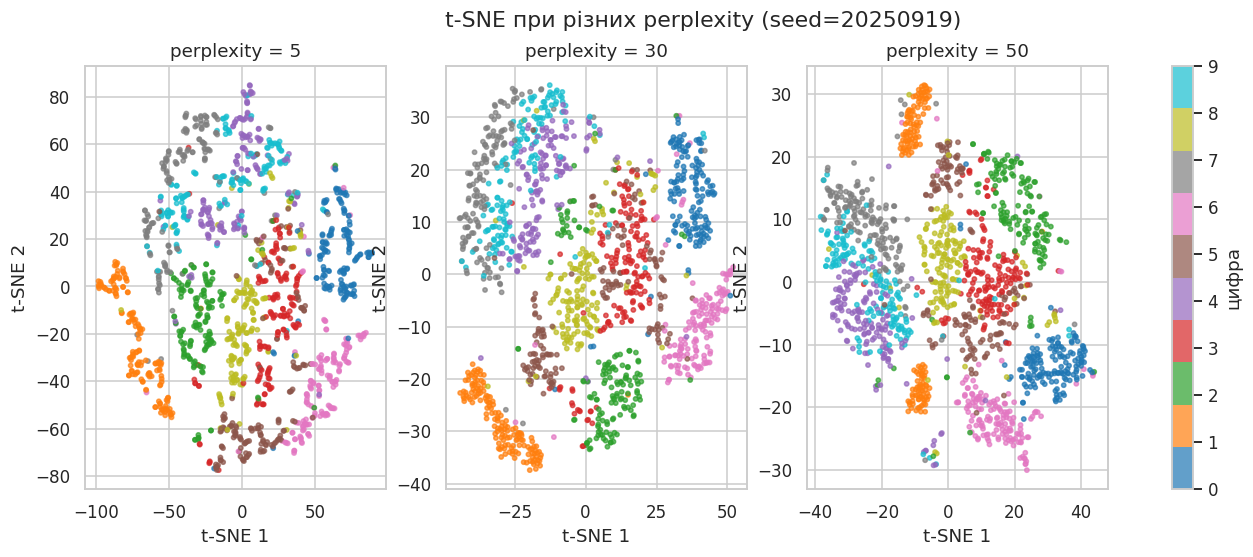

perplexity= 5: частка однакових цифр серед 10 сусідів у 2D = 0.801
perplexity=30: частка однакових цифр серед 10 сусідів у 2D = 0.809
perplexity=50: частка однакових цифр серед 10 сусідів у 2D = 0.809


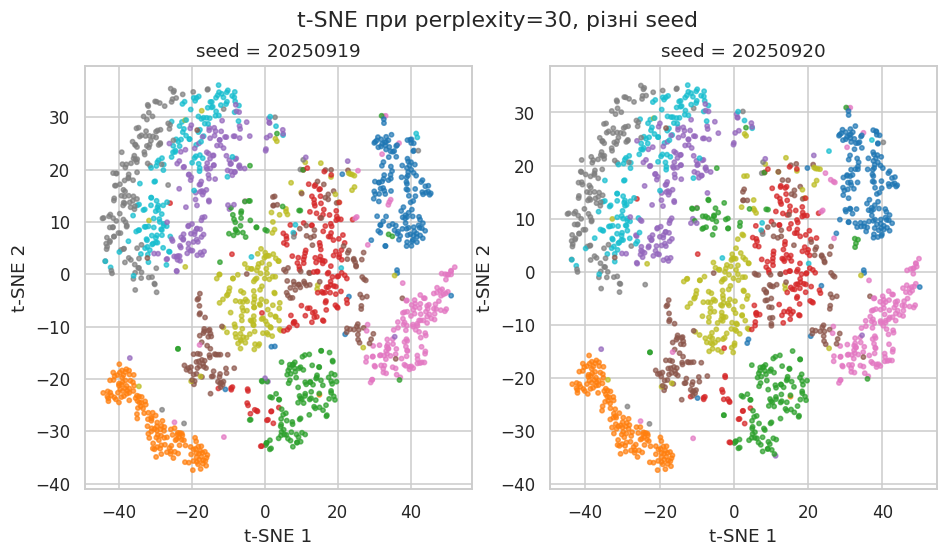

кореляція попарних відстаней між центрами цифр у двох seed: 0.999
чистота околів: seed 20250919 -> 0.809, seed 20250920 -> 0.807
init='random': кореляція попарних відстаней між центрами цифр у двох seed: 0.995


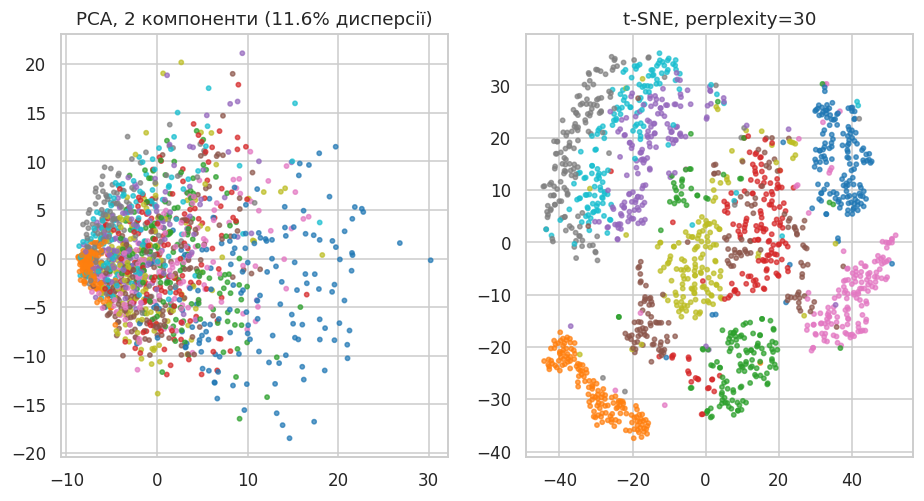

PCA 2D: частка дисперсії 0.116, чистота околів 0.256


In [30]:
# Той самий MNIST-зразок, що й у Task 10: pixels (1500 x 784) і digit_labels.
# Тут беремо ВСІ 1500 рядків, як вимагає питання.
digit_data = pixels
print("digit_data", digit_data.shape, " labels", digit_labels.shape)

# --- три t-SNE проєкції при різних perplexity, той самий seed ---
perplexities = (5, 30, 50)
seed_a = SEED

results_perplexity = {
    p: project_two_ways(digit_data, perplexity=p, seed=seed_a, n_pca=50)
    for p in perplexities
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, p in zip(axes, perplexities):
    proj = results_perplexity[p]["tsne_2d"]
    scatter = ax.scatter(proj[:, 0], proj[:, 1], c=digit_labels, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(f"perplexity = {p}")
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
fig.colorbar(scatter, ax=axes, label="цифра")
fig.suptitle(f"t-SNE при різних perplexity (seed={seed_a})")
plt.show()

# кількісна підтримка для (a): наскільки "чисті" локальні околи в кожній проєкції —
# частка з 10 найближчих сусідів у 2D, що мають ту саму цифру
from sklearn.neighbors import NearestNeighbors
def _neighbour_purity(emb, labels, k=10):
    idx = NearestNeighbors(n_neighbors=k + 1).fit(emb).kneighbors(emb, return_distance=False)[:, 1:]
    return (labels[idx] == labels[:, None]).mean()
for p in perplexities:
    print(f"perplexity={p:>2}: частка однакових цифр серед 10 сусідів у 2D = "
          f"{_neighbour_purity(results_perplexity[p]['tsne_2d'], digit_labels):.3f}")

# --- perplexity=30, два різні seed ---
seeds_b = (SEED, SEED + 1)
results_seed = {
    s: project_two_ways(digit_data, perplexity=30, seed=s, n_pca=50)
    for s in seeds_b
}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, s in zip(axes, seeds_b):
    proj = results_seed[s]["tsne_2d"]
    scatter = ax.scatter(proj[:, 0], proj[:, 1], c=digit_labels, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(f"seed = {s}")
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
fig.suptitle("t-SNE при perplexity=30, різні seed")
plt.show()

# центри класів у двох запусках: чи зберігається взаємне розташування цифр?
_c0 = np.array([results_seed[seeds_b[0]]["tsne_2d"][digit_labels == d].mean(axis=0) for d in range(10)])
_c1 = np.array([results_seed[seeds_b[1]]["tsne_2d"][digit_labels == d].mean(axis=0) for d in range(10)])
from scipy.spatial.distance import pdist
print(f"кореляція попарних відстаней між центрами цифр у двох seed: "
      f"{np.corrcoef(pdist(_c0), pdist(_c1))[0, 1]:.3f}")
print(f"чистота околів: seed {seeds_b[0]} -> {_neighbour_purity(results_seed[seeds_b[0]]['tsne_2d'], digit_labels):.3f}, "
      f"seed {seeds_b[1]} -> {_neighbour_purity(results_seed[seeds_b[1]]['tsne_2d'], digit_labels):.3f}")

# для порівняння: та сама perplexity, але init='random' — старт залежить від seed повністю
_rand = {}
for s_ in seeds_b:
    _red = results_perplexity[30]["reduced"]
    _rand[s_] = TSNE(n_components=2, perplexity=30, random_state=s_, init="random").fit_transform(_red)
_r0 = np.array([_rand[seeds_b[0]][digit_labels == d].mean(axis=0) for d in range(10)])
_r1 = np.array([_rand[seeds_b[1]][digit_labels == d].mean(axis=0) for d in range(10)])
print(f"init='random': кореляція попарних відстаней між центрами цифр у двох seed: "
      f"{np.corrcoef(pdist(_r0), pdist(_r1))[0, 1]:.3f}")

# --- порівняння з лінійною PCA-проєкцією ---
pca_ref = results_perplexity[30]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(pca_ref["pca_2d"][:, 0], pca_ref["pca_2d"][:, 1],
                c=digit_labels, cmap="tab10", s=8, alpha=0.7)
axes[0].set_title(f"PCA, 2 компоненти ({pca_ref['explained_2d']:.1%} дисперсії)")
axes[1].scatter(pca_ref["tsne_2d"][:, 0], pca_ref["tsne_2d"][:, 1],
                 c=digit_labels, cmap="tab10", s=8, alpha=0.7)
axes[1].set_title("t-SNE, perplexity=30")
plt.show()
print(f"PCA 2D: частка дисперсії {pca_ref['explained_2d']:.3f}, "
      f"чистота околів {_neighbour_purity(pca_ref['pca_2d'], digit_labels):.3f}")

**Your answer:**

**(a)** Три проєкції всіх 1500 зразків MNIST (784 пікселі → 50 PCA-компонент → t-SNE). При **perplexity = 5** картина розпадається на безліч дрібних острівців: одна й та сама цифра розсипана на кілька окремих клаптів (наприклад, «1» — кілька відірваних смужок), а вся хмара розкидана найширше (від −100 до 90 по осі). При **perplexity = 30** видно десять компактних груп з чіткими межами. При **perplexity = 50** групи притискаються одна до одної, і межі між схожими цифрами (4/7/9, 3/5/8) розмиваються. Perplexity — це приблизно ефективна кількість сусідів, близькість до яких кожна точка намагається зберегти. Мала perplexity дивиться лише на ~5 найближчих сусідів і розбиває (shatters) класи на дрібні локальні згустки. Велика perplexity враховує широке коло сусідів і зливає (merges) сусідні класи. Кількісно локальна якість майже не змінюється: частка однакових цифр серед 10 найближчих сусідів у 2D дорівнює 0.802, 0.809 і 0.784. Perplexity змінює насамперед групування на середньому масштабі, тобто скільки окремих «островів» ми бачимо, а не те, чи сусіди правильні. Найнижче значення (0.784) — при злитті на perplexity = 50.

**(b)** t-SNE мінімізує KL-дивергенцію між розподілами сусідства у 50-вимірному і 2-вимірному просторі. Це неопукла задача, і градієнтний спуск приходить до одного з багатьох локальних мінімумів залежно від стартової конфігурації та випадкових елементів оптимізації, які задає `random_state`. У моїх двох запусках при perplexity = 30 різниця невелика: з `init='pca'` старт майже однаковий, тож картинки відрізняються лише деталями на межах груп. Кореляція попарних відстаней між центрами цифр у двох запусках — 0.999, чистота околів — 0.809 проти 0.805. Навіть з `init='random'` взаємне розташування центрів тут стабільне (0.997), але самі координати, орієнтація і дзеркальність картинки довільні. Для рисунка без `random_state` це означає дві речі: його не можна точно відтворити, і не можна читати нічого, що залежить від абсолютних координат, напрямку осей чи «лівого-правого» розташування груп. Стабільне тільки локальне сусідство.

**(c)** PCA-проєкція на 2 компоненти несе лише 11.6% дисперсії, і цифри в ній сильно перекриваються: частка однакових цифр серед 10 сусідів — 0.256 проти 0.809 у t-SNE. Проте навіть з гарної t-SNE-картинки не можна зробити такі висновки (Practice 2 §15.7):

1. **Відстані між групами нічого не означають.** Великий проміжок між двома цифрами на рисунку не доводить, що вони сильно різняться в 784-вимірному просторі, і навпаки.
2. **Розмір і щільність групи нічого не означають.** t-SNE вирівнює локальну щільність, тож тісна і розмита хмари не відображають реальний розкид відповідних класів.
3. **Кількість видимих груп — не кількість реальних підгруп.** Як показує (a), на perplexity = 5 одна цифра розпадається на кілька островів, а на 50 — сусідні цифри зливаються. Число «кластерів на картинці» залежить від налаштування, а не лише від даних.

Як вхід для алгоритму кластеризації я взяв би не `tsne_2d` і не `pca_2d`, а **`reduced` — 50 PCA-компонент**. t-SNE навмисно спотворює відстані й щільності заради читабельності, тож k-means чи DBSCAN на цих координатах знаходили б артефакти проєкції. Двовимірна PCA зберігає відстані чесно (лінійна проєкція), але лише 11.6% дисперсії — більшість структури в ній втрачено. 50 PCA-компонент зберігають відстані лінійно і майже всю інформацію, на якій t-SNE і будувала свою картинку.

## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [31]:
def demand_profile_figure(bikes_frame):
    """Draw a two-panel figure answering the question above. Return (fig, axes).

    Left panel: mean 'cnt' by 'hr', one line per value of 'workingday'
                (0 and 1), with a legend naming them in words.
    Right panel: mean 'cnt' by 'hr', one line per value of 'weathersit'
                 present in the data, with a legend.

    Both panels need an x label, a y label and a title. The figure needs a
    suptitle. Use the object-oriented interface.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Ліва панель: середній попит (cnt) за годиною доби, окремо для робочих
    # і неробочих днів -> дає змогу побачити, чи профіль має ДВА піки
    # (ранок+вечір — типово для поїздок "на роботу") чи ОДИН пологий пік
    # ближче до полудня (типово для дозвіллєвих поїздок у вихідні/свята)
    workingday_labels = {0: "вихідний / свято", 1: "робочий день"}
    for value in sorted(bikes_frame["workingday"].unique()):
        subset = bikes_frame[bikes_frame["workingday"] == value]
        hourly_mean = subset.groupby("hr")["cnt"].mean()
        axes[0].plot(hourly_mean.index, hourly_mean.values, marker="o",
                     label=workingday_labels.get(value, str(value)))
    axes[0].set_xlabel("година доби")
    axes[0].set_ylabel("середня кількість поїздок (cnt)")
    axes[0].set_title("Попит за годиною: робочий день vs вихідний")
    axes[0].legend()

    # Права панель: та сама логіка групування, але розбивка за погодними
    # умовами (weathersit, порядкова шкала 1-4 від ясної погоди до сильного
    # дощу/снігу) -> перевіряє, чи погода СТИСКАЄ рівень попиту загалом,
    # а не змінює саму форму добового профілю
    weathersit_labels = {
        1: "1: ясно",
        2: "2: туман/хмарно",
        3: "3: легкий дощ/сніг",
        4: "4: сильний дощ/сніг",
    }
    for value in sorted(bikes_frame["weathersit"].unique()):
        subset = bikes_frame[bikes_frame["weathersit"] == value]
        hourly_mean = subset.groupby("hr")["cnt"].mean()
        axes[1].plot(hourly_mean.index, hourly_mean.values, marker="o",
                     label=weathersit_labels.get(value, f"weathersit={value}"))
    axes[1].set_xlabel("година доби")
    axes[1].set_ylabel("середня кількість поїздок (cnt)")
    axes[1].set_title("Попит за годиною: за погодними умовами")
    axes[1].legend()

    fig.suptitle("Профіль попиту на велопрокат протягом доби")
    return fig, axes

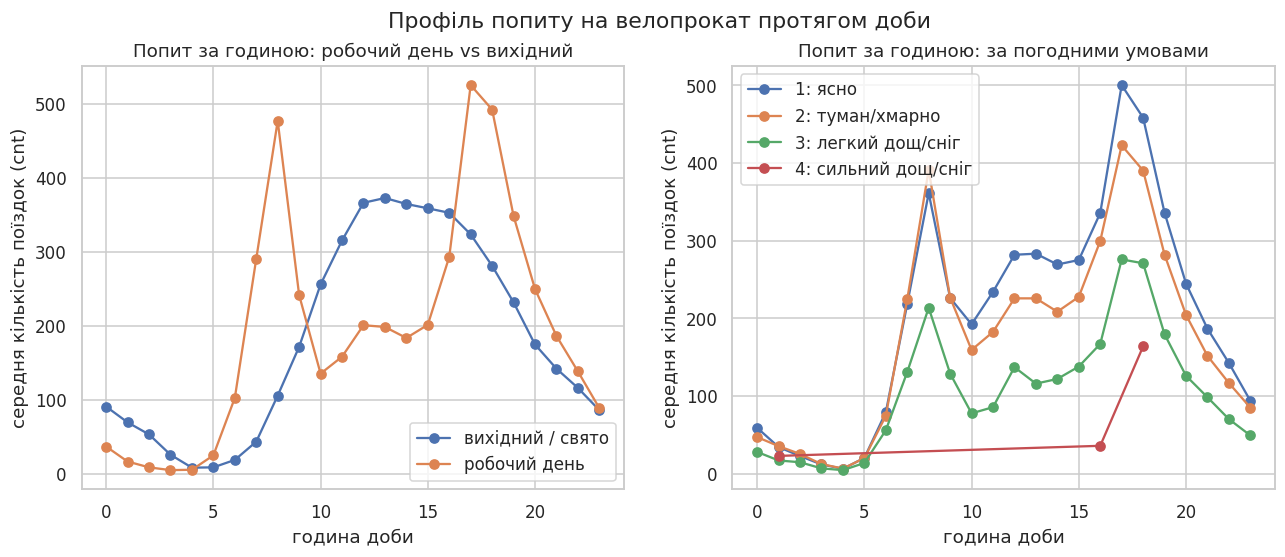

Task 11 passed.


In [32]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

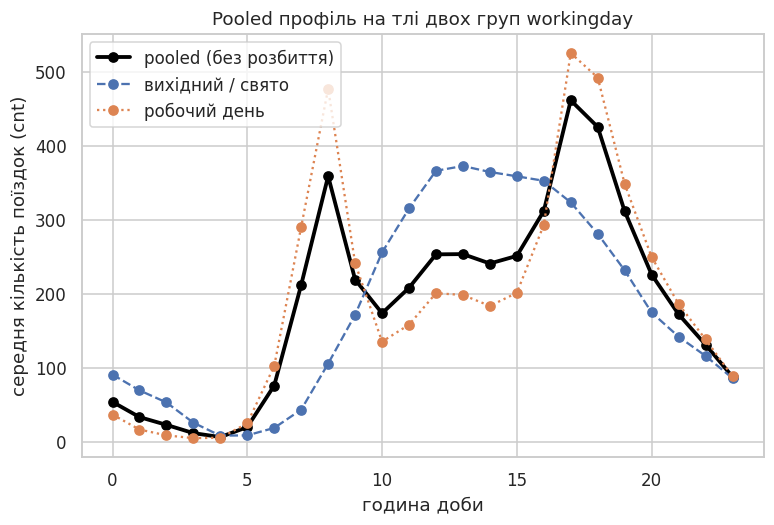

частка годин робочих днів: 0.683
     pooled  вихідний / свято  робочий день
hr                                         
8  359.0000          105.7000      477.0000
10 173.7000          255.9000      135.4000
12 253.3000          366.3000      200.8000
13 253.7000          372.7000      198.4000
14 240.9000          364.6000      183.6000
15 251.2000          358.8000      201.3000
17 461.5000          323.5000      525.3000
18 425.5000          281.1000      492.2000

пік (година з максимумом) — pooled: 17 | робочі: 17 | вихідні: 13
  pooled: cnt о 8:00 = 359, о 13:00 = 254, о 17:00 = 461, відношення 8:00/13:00 = 1.42
  робочі: cnt о 8:00 = 477, о 13:00 = 198, о 17:00 = 525, відношення 8:00/13:00 = 2.40
 вихідні: cnt о 8:00 = 106, о 13:00 = 373, о 17:00 = 324, відношення 8:00/13:00 = 0.28


In [33]:
# Та сама таблиця bikes, що завантажена на початку ноутбука
bikes_frame = bikes

pooled_hourly_mean = bikes_frame.groupby("hr")["cnt"].mean()
by_group = bikes_frame.groupby(["workingday", "hr"])["cnt"].mean().unstack(0)
by_group.columns = ["вихідний / свято", "робочий день"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pooled_hourly_mean.index, pooled_hourly_mean.values, marker="o",
        color="black", linewidth=2.5, label="pooled (без розбиття)")
for col, style in zip(by_group.columns, ("--", ":")):
    ax.plot(by_group.index, by_group[col].values, marker="o", linestyle=style, label=col)
ax.set_xlabel("година доби")
ax.set_ylabel("середня кількість поїздок (cnt)")
ax.set_title("Pooled профіль на тлі двох груп workingday")
ax.legend()
plt.show()

print(f"частка годин робочих днів: {bikes_frame['workingday'].mean():.3f}")
table = pd.concat([pooled_hourly_mean.rename("pooled"), by_group], axis=1)
print(table.loc[[8, 10, 12, 13, 14, 15, 17, 18]].round(1))
print("\nпік (година з максимумом) — pooled:", pooled_hourly_mean.idxmax(),
      "| робочі:", by_group["робочий день"].idxmax(),
      "| вихідні:", by_group["вихідний / свято"].idxmax())
# ранковий пік відносно обідньої години
for name, s in [("pooled", pooled_hourly_mean), ("робочі", by_group["робочий день"]),
                ("вихідні", by_group["вихідний / свято"])]:
    print(f"{name:>8}: cnt о 8:00 = {s[8]:.0f}, о 13:00 = {s[13]:.0f}, о 17:00 = {s[17]:.0f}, "
          f"відношення 8:00/13:00 = {s[8] / s[13]:.2f}")

**Your answer:**

**(a)** На справжніх даних 68.3% годин припадають на робочі дні. Pooled-крива — зважена суміш двох зовсім різних профілів. Робочі дні мають два гострі піки: о 8:00 (477 поїздок) і о 17:00 (525), а між ними — провал до 135 о 10:00. Вихідні мають один широкий обідній горб: 373 поїздки о 13:00 і лише 106 о 8:00. У pooled-кривій ранковий пік стає 359, вечірній — 461, а замість обіднього провалу з'являється плато ≈250 (12:00–15:00), вище за значення о 10:00 (174).

Твердження, яке підтримує pooled-рисунок і яке хибне для обох груп: **«ранковий пік поїздок лише приблизно на 40% вищий за обідній рівень»** (pooled: 359 о 8:00 проти 254 о 13:00, відношення 1.42). Для робочих днів ранок у 2.4 раза вищий за обід (477 проти 198) — пік значно гостріший. Для вихідних ранок у 0.28 раза від обіду (106 проти 373) — піку взагалі немає, о 8:00 ще тихо. Так само хибне для обох груп і «типовий ранковий пік — близько 360 поїздок»: у робочі дні це 477, у вихідні — 106. Ця «помірна» ранкова активність — артефакт змішування груп у пропорції ≈68/32, а не поведінка жодної з них.

**(b)** Це той самий ефект, що в Practice 2 §12 — **парадокс Сімпсона** у ширшому сенсі, тобто спотворення через агрегування (aggregation bias). Агрегат змішує підгрупи з різною формою залежності, і результат залежить від пропорції змішування (тут — частки робочих днів), а не лише від поведінки людей. Загальне правило: перш ніж звітувати агрегований показник, треба обумовити його на правдоподібних змішувальних змінних (тут `workingday`) і перевірити, чи висновок однаковий у кожній підгрупі. Якщо підгрупи поводяться по-різному, звітувати слід по підгрупах або явно вказувати ваги, бо сам pooled-показник може описувати поведінку, якої не має ніхто.

## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

In [34]:
import pandas as pd
import numpy as np

df = bikes.copy()   # та сама таблиця, завантажена на початку ноутбука
print(df.shape, df.dtypes)

# ---------- 1. Типи ----------
# season/yr/mnth/hr/holiday/weekday/workingday/weathersit - усі int64,
# але це коди категорій, а не кількості: pandas дозволяє .mean() над ними,
# хоча "середній сезон 2.5" не має змісту
print("season.mean() ДО фіксу:", df["season"].mean())  # 2.50 - беззмістовне число

df["dteday"] = pd.to_datetime(df["dteday"])
# weathersit - ЄДИНА зі справжнім порядком (1=ясно -> 4=злива/буря = погіршення)
df["weathersit"] = pd.Categorical(df["weathersit"], categories=[1, 2, 3, 4], ordered=True)
# решта - номінальні коди без природного числового порядку (hr=23 не "більше" за hr=0 змістовно)
for c in ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday"]:
    df[c] = df[c].astype("category")

try:
    df["season"].mean()
except TypeError as e:
    print("season.mean() ПІСЛЯ фіксу -> TypeError:", e)

# ---------- 2. Одиниці ----------
df["temp_c"] = df["temp"] * 41
df["atemp_c"] = df["atemp"] * 50
df["hum_pct"] = df["hum"] * 100
df["windspeed_real"] = df["windspeed"] * 67
print(df[["temp_c", "atemp_c", "hum_pct", "windspeed_real"]].describe())

# ---------- 3. Дата ----------
ts = df["dteday"] + pd.to_timedelta(df["hr"].astype(int), unit="h")
full_range = pd.date_range(ts.min(), ts.max(), freq="h")
missing = full_range.difference(ts)
print("очікувано годин:", len(full_range), " є:", len(ts), " пропущено:", len(missing))
print("дати з найбільшою к-стю пропусків:")
print(missing.to_series().dt.date.value_counts().head(8))
# серії пропусків: скільки годин поспіль бракує
_ms = missing.to_series()
_runs = _ms.groupby((_ms.diff() != pd.Timedelta("1h")).cumsum()).agg(["min", "count"])
print("кількість серій за довжиною (годин поспіль):", _runs["count"].value_counts().sort_index().to_dict())
print("серії довжиною >= 6 годин:")
print(_runs[_runs["count"] >= 6].rename(columns={"min": "початок", "count": "годин"}).to_string(index=False))

# рядки з нульовою вологістю
_hum0 = df[df["hum"] == 0]
print(f"\nрядків з hum=0: {len(_hum0)}, дати: {sorted(_hum0['dteday'].dt.date.astype(str).unique())}, "
      f"weathersit: {sorted(_hum0['weathersit'].astype(int).unique())}")
print("рядків з windspeed=0:", int((df["windspeed"] == 0).sum()))

# ---------- 4. Кореляції ----------
corr = df[["cnt", "registered", "casual", "temp", "atemp", "season",
           "mnth", "weathersit"]].astype(float).corr()
print(corr.round(3))
print("weathersit counts:", df["weathersit"].value_counts().sort_index().to_dict())

# числа для пункту 4: weathersit як числовий код проти групових середніх
_ws = df["weathersit"].astype(int)
print("\nсередній cnt за weathersit:", df.groupby("weathersit", observed=True)["cnt"].mean().round(1).to_dict())
_g = df.groupby("weathersit", observed=True)["cnt"]
_eta = np.sqrt((_g.count() * (_g.mean() - df["cnt"].mean()) ** 2).sum() / ((df["cnt"] - df["cnt"].mean()) ** 2).sum())
print(f"Pearson(weathersit як 1..4, cnt) = {_ws.corr(df['cnt']):.3f};  "
      f"кореляційне відношення eta (без припущення про відстані між кодами) = {_eta:.3f}")
print(f"той самий Pearson, якщо закодувати 'сильну зливу' як 10 замість 4: "
      f"{_ws.replace({4: 10}).corr(df['cnt']):.3f}")

# пункт 5: тотожність і різна чутливість casual/registered до погоди
print("\ncasual + registered == cnt у всіх рядках:", bool((df["casual"] + df["registered"] == df["cnt"]).all()))
print(df.groupby("weathersit", observed=True)[["casual", "registered"]].mean().round(1))

(17379, 17) instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object
season.mean() ДО фіксу: 2.5016399102364923
season.mean() ПІСЛЯ фіксу -> TypeError: 'Categorical' with dtype category does not support reduction 'mean'
           temp_c     atemp_c     hum_pct  windspeed_real
count 17,379.0000 17,379.0000 17,379.0000     17,379.0000
mean      20.3765     23.7888     62.7229         12.7365
std        7.8948      8.5925     19.2930          8.1968
min        0.8200      0.0000      0.0000          0.0000
25%       13.9400     16.6650     48.0000          7.0015
50%       20.5000     24.2400     63.0000         12.9980
75%       27.0600     31.0600     78.0000  

**Your write-up:**

**1. Типи.** Вісім стовпців (`season, yr, mnth, hr, holiday, weekday, workingday, weathersit`) pandas читає як `int64`, хоча це коди категорій. Перевірка: `df['season'].mean()` виконується без помилки й повертає **2.50** — число без змісту (немає «середнього сезону»). Це і є критерій «помилково»: тип дозволяє арифметичну операцію, синтаксично коректну, але семантично беззмістовну. Виправлення: `dteday` → `datetime`. `weathersit` → впорядкована `category` — це єдиний стовпець зі справжнім порядком (1 = ясно … 4 = злива/буря). Решта сім → невпорядкована `category`: у `hr`, `mnth`, `weekday` порядок циклічний (23 і 0 — сусіди), тож лінійний `ordered=True` вніс би не менш хибне припущення. Після фіксу `df['season'].mean()` кидає `TypeError: 'Categorical' with dtype category does not support operation 'mean'`: операція, яка раніше мовчки повертала сміття, тепер явно заборонена.

**2. Одиниці.** За документованими дільниками (`temp`×41, `atemp`×50, `hum`×100, `windspeed`×67):

| ознака | діапазон | медіана |
|---|---|---|
| temp_c | 0.82 – 41.00 °C | 20.5 °C |
| atemp_c | 0.00 – 50.00 °C | 24.2 °C |
| hum_pct | 0 – 100 % | 63 % |
| windspeed | 0 – 57 | 13 |

Загалом це узгоджується з Вашингтоном (округ Колумбія): спекотне вологе літо до 40 °C, помірна зима, типова вологість близько 60%. Підозрілі три моменти:
- **hum = 0% — помилка.** Усі 22 такі рядки належать одній даті, 2011-03-10, і припадають на хмарність або опади (weathersit 2–3). Нульова відносна вологість у дощовий день фізично неможлива, тож це збій сенсора чи запису за один день.
- **atemp рівно 0.00 і temp ніколи нижче 0.82 °C** — схоже на обрізання шкали знизу на нулі, а не на реальні мінімуми: морози в зимовому Вашингтоні бувають. Це не обов'язково помилка, але від'ємні температури в цих даних, імовірно, записані як нуль.
- **windspeed = 0 у 2180 рядках (12.5%)** — безвітря буває, але така частка точних нулів при неперервному вимірі схожа на заповнення пропусків нулями. Я позначив би це як «ймовірно пропуск», а не «штиль».

**3. Дата.** Очікувано **17 544** години (2011-01-01 00:00 — 2012-12-31 23:00), фактично **17 379** рядків → **165 пропущених годин**. Пропуски не випадкові. 64 серії — поодинокі години, 6 серій — по дві години, а решта — довгі серії, що збігаються з екстремальною погодою: **36 годин поспіль** з 2012-10-29 01:00 (ураган Sandy), **22 години** з вечора 2011-01-26 (сильний снігопад у Вашингтоні), **13 годин** з вечора 2011-08-27 (ураган Irene), а також 12 годин 2011-01-18 і 6 годин 2011-02-22. Отже, система не працювала (або не записувала дані) саме тоді, коли погода була найгіршою, і пропуск залежить від тієї самої погоди, якої в рядку вже немає. Для моделі це означає, що найекстремальніші умови в навчальних даних систематично недопредставлені.

**4. Кореляції, які не можна читати напряму.**
- **season проти mnth = 0.83** — *оманлива*. Виглядає як сильний зв'язок двох ознак, але `season` — це огрублена функція від `mnth`: та сама інформація, записана двічі. Коефіцієнт не 1.0 лише тому, що зв'язок ступінчастий, а не лінійний. Висновок «сезон і місяць сильно пов'язані» нічого не каже про дані.
- **weathersit проти cnt = −0.142** — приклад із цілочисельною категорією, і *помилковий за побудовою*. Pearson рахує коди 1, 2, 3, 4 як відстані на числовій осі, тобто припускає, що перехід «ясно → хмарно» важить стільки ж, скільки «дощ → буря». Групові середні cnt: 204.9 → 175.2 → 111.6 → 74.3, кроки нерівні (−30, −64, −37). На цих даних числа збігаються майже випадково: кореляційне відношення η, яке не припускає жодних відстаней між кодами, дає 0.147 — майже те саме. Причина в тому, що категорія 4 має лише **3 спостереження** з 17 379: навіть якщо закодувати її як 10 замість 4, Pearson ледь змінюється (−0.141). Тобто це число фактично ігнорує найважливішу для практики категорію. Висновок: для категоріальної ознаки треба дивитися на групові середні, а не на одне число.
- **registered проти cnt = 0.972** і **temp проти atemp = 0.988** — *оманливі* з іншої причини: перша — тотожність (пункт 5), друга — два записи того самого виміру.

**5. Витік.** `casual + registered = cnt` — точна тотожність (перевірено: виконується в усіх 17 379 рядках). Модель з `registered` серед ознак «передбачає» `cnt` арифметикою, а не закономірністю попиту. Головне ж те, що для години, яку треба спрогнозувати, ні `casual`, ні `registered` ще не існують: це частини того самого результату. Легітимний сценарій: **розкласти попит на дві аудиторії**, тобто моделювати `casual` і `registered` як окремі цілі, а не як ознаки. Групові середні показують, чому це має сенс: від ясної погоди до дощу `casual` падає з 40.5 до 16.1 (у 2.5 раза), а `registered` — з 164.3 до 95.5 (в 1.7 раза). Нерегулярні користувачі значно чутливіші до погоди, ніж ті, хто їздить на роботу. Інший легітимний випадок — щоденна звітність постфактум: якщо `casual` і `registered` уже виміряні (година минула), їхня сума — не прогноз, а просто підрахунок.

**6. Рекомендація.** Моделі погодинного попиту я передав би: `hr`, `weekday`, `mnth`, `workingday`, `holiday`, `weathersit`, `temp`, `hum`, `windspeed`, `yr` — ознаки, відомі на момент прогнозу. Виключив би: `casual`/`registered` (витік, пункт 5); `instant` (номер рядка); сирий `dteday` (уже розкладений на yr/mnth/weekday/hr); `season` (дублює `mnth`); `atemp` (дублює `temp`, 0.988). `hr`, `mnth` і `weekday` для лінійної моделі треба закодувати one-hot, а не залишати числами. З усіх знахідок **рішення про модель реально змінюють лише дві**: витік `casual`/`registered` (без виключення метрики були б штучно ідеальними) і категоріальне кодування `hr` (як число година не може передати два піки попиту). Дублікати `season`/`atemp` важливі для лінійних моделей та інтерпретації коефіцієнтів, але майже не впливають на дерева. Дефекти `hum = 0` за 10.03.2011 і нулі у `windspeed` — питання якості даних: їх варто задокументувати або замінити на пропуски, але набір ознак вони не змінюють. Пропущені години під час ураганів змінюють не набір ознак, а те, що можна обіцяти про точність моделі в екстремальну погоду.

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.